# MENS ONLY - xG Prediction

### Imports and loading

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR = Path().resolve().parent / "Additional"
df = pd.read_parquet(DATA_DIR / "for_regression.parquet")
df = df[df['OFF_MEN_WOMEN'] == 'M'].copy()
print(df.head(10))
print(df.shape)
print(list(df.columns))

print(f"Unique match,team,period, possession combos: {df.groupby(['match_id','OFF_TEAM_ID','period','possession']).ngroups}")
print(f"Total rows: {len(df)}")
print(f"\ntotal_xg stats:")
print(df['total_xg'].describe())
print(f"\nn_shots stats:")
print(df['n_shots'].describe())
print(f"\nRows per match_id (sample):")
print(df.groupby('match_id').size().describe())

shot_df = df[df['n_shots'] > 0]
print(f"Shot-producing rows: {len(shot_df)}")
print(f"Shot rate: {len(shot_df)/len(df):.4f}")
print(f"\ntotal_xg on shot rows:")
print(shot_df['total_xg'].describe())

print(f"\nlog_xg mean: {np.log(shot_df['total_xg']).mean():.4f}")
print(f"log_xg skewness: {np.log(shot_df['total_xg']).skew():.4f}")

    match_id           possession_type  period  possession  OFF_TEAM_ID  \
0    3825722   Attacking Third - Short       2         145         1041   
1    3754346  Defensive Third - Direct       2         111           36   
2    3754256     Middle Third - Direct       1          36           39   
3    3857290   Attacking Third - Short       2         174         2722   
5    3829428     Middle Third - Direct       1          44          130   
6    3879554      Middle Third - Short       2         187         2256   
7     303479     Middle Third - Direct       1          54          210   
8    3754339      Middle Third - Short       2         136           30   
9       7572      Middle Third - Short       1          52          778   
10   3869117      Middle Third - Short       2         144          941   

   OFF_MEN_WOMEN  OFF_BACKS  OFF_MIDFIELDERS  OFF_FORWARDS  OFF_GOALKEEPER  \
0              M        4.0              4.0           2.0             1.0   
1              M  

### Data Prep

In [2]:
shot_df = df[df['n_shots'] > 0].copy()
shot_df['log_xg'] = np.log(shot_df['total_xg'])
df_model = pd.get_dummies(shot_df, columns=['possession_type'], drop_first=True)

for c in ['C0', 'C1', 'C2', 'C3']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

# ADD THIS
for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2',
     'DIFF_GK_C0', 'DIFF_GK_C1']  #DIFF_GK_C2 dropped as implicit reference
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

print(f"Shape: {df_model.shape}")
print(f"Nulls: {df_model[feature_cols + ['log_xg']].isnull().sum().sum()}")
print(f"log_xg mean: {df_model['log_xg'].mean():.4f}, std: {df_model['log_xg'].std():.4f}")
print(f"Shot-producing rows: {len(shot_df)}")

Shape: (65103, 53)
Nulls: 0
log_xg mean: -2.8263, std: 1.1287
Shot-producing rows: 65103


### Multicollinearity check

In [3]:
X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string())
print(f"Shape: {df_model.shape}")

                                      feature       VIF
5                                  DIFF_GK_C1  2.845399
4                                  DIFF_GK_C0  2.116429
3                                     DIFF_C2  1.661767
1                                     DIFF_C0  1.586249
0                            duration_minutes  1.412971
2                                     DIFF_C1  1.360387
7    possession_type_Defensive Third - Direct  1.137366
11     possession_type_Middle Third - Patient  1.126804
10      possession_type_Middle Third - Direct  1.090695
12       possession_type_Middle Third - Short  1.025239
9     possession_type_Defensive Third - Short  1.024867
6     possession_type_Attacking Third - Short  1.019442
8   possession_type_Defensive Third - Patient  1.013514
Shape: (65103, 53)


### Train/Test and Scaling

In [4]:
X = df_model[feature_cols].astype(float)
y = df_model['log_xg']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Fit

In [5]:
# sklearn for performance metrics
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²: {r2:.4f}")
print(f"RMSE (log scale): {rmse:.4f}")
print(f"RMSE (xg scale, approx): {np.exp(rmse):.4f}")

R²: 0.0122
RMSE (log scale): 1.1207
RMSE (xg scale, approx): 3.0670


### Inference

In [6]:
# statsmodels for inference
X_train_sm = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_sm)
result = ols_model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 log_xg   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     50.87
Date:                Mon, 13 Apr 2026   Prob (F-statistic):          4.71e-132
Time:                        22:22:22   Log-Likelihood:                -79891.
No. Observations:               52082   AIC:                         1.598e+05
Df Residuals:                   52068   BIC:                         1.599e+05
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8259      0.005   -574.760      0.0

### Add variable names back

In [7]:
feature_names = ['const'] + feature_cols
results_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'exp_coef': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('exp_coef', ascending=False)
print(results_df.to_string())

                                     variable  coefficient  exp_coef       p_value
3                                     DIFF_C1     0.079347  1.082580  1.499689e-43
2                                     DIFF_C0     0.066610  1.068878  2.040828e-27
6                                  DIFF_GK_C1     0.060188  1.062036  2.875885e-13
5                                  DIFF_GK_C0     0.056563  1.058193  2.457260e-15
11      possession_type_Middle Third - Direct     0.028212  1.028613  3.961522e-04
1                            duration_minutes     0.022925  1.023190  1.994825e-05
7     possession_type_Attacking Third - Short     0.019764  1.019961  2.991193e-02
8    possession_type_Defensive Third - Direct     0.012130  1.012204  1.543703e-01
10    possession_type_Defensive Third - Short     0.010190  1.010242  2.196067e-01
4                                     DIFF_C2     0.009817  1.009866  1.177761e-01
9   possession_type_Defensive Third - Patient    -0.007522  0.992507  1.430239e-01
12  

### Cross Validation

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
print(f"\nCV R² scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV R² scores: [0.0109196  0.01579744 0.01339076 0.01127732 0.00765894]
Mean: 0.0118 (+/- 0.0027)


### Results and Viz

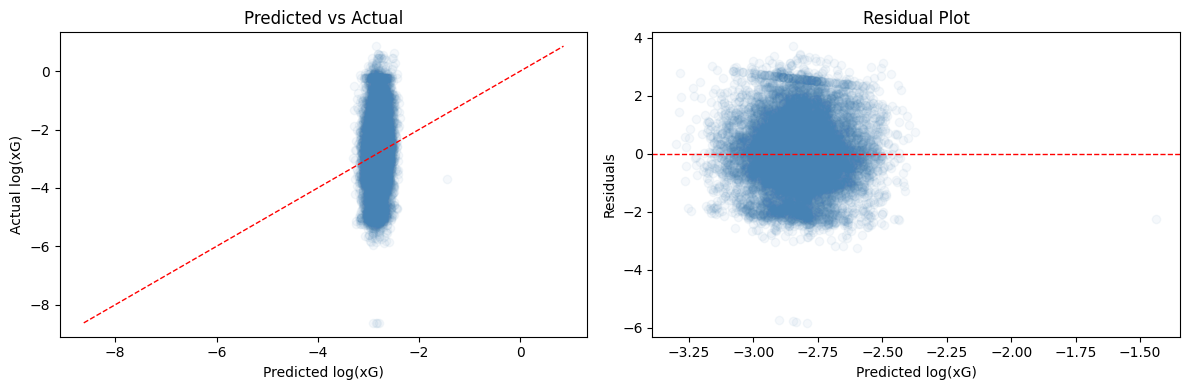

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, y_test, alpha=0.05, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=1)
axes[0].set_xlabel('Predicted log(xG)')
axes[0].set_ylabel('Actual log(xG)')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.05, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted log(xG)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()


### Log Odds Graphs

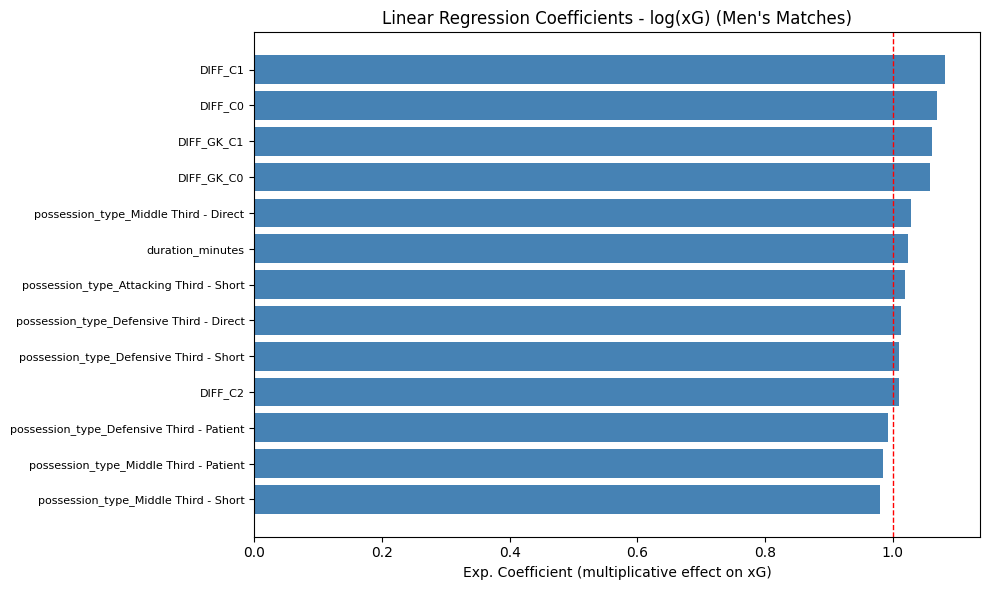

In [10]:
full_plot = results_df.sort_values('exp_coef')
plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['exp_coef'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Exp. Coefficient (multiplicative effect on xG)')
plt.title('Linear Regression Coefficients - log(xG) (Men\'s Matches)')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

### Summary

**Summary: We ran a linear regression model predicting log(xG) on men's shot-producing possessions (n = 65,103), using possession type, player type cluster differentials (C0–C2, with C3 as implicit reference), goalkeeper cluster differentials (GK_C0 and GK_C1, with GK_C2 as implicit reference), and duration. Response variable is log-transformed to address right skew; exponentiated coefficients represent multiplicative effects on xG.**

Highlights:

* DIFF_C1 is strongest positive cluster effect (exp coef 1.083)
* DIFF_C0 is also positive and significant (exp coef 1.069)
* DIFF_GK_C1 is positive and significant (exp coef 1.062). Having a GK_C1-type goalkeeper advantage is associated with higher xG quality
* DIFF_GK_C0 is also positive and significant (exp coef 1.058)
* Duration is positive and significant (exp coef 1.023). Longer possessions are associated with modestly higher xG quality
* "Middle Third - Direct" has the strongest positive possession type effect (exp coef 1.029)
* Several features are not significant: DIFF_C2 (p=0.118), Defensive Third - Direct (p=0.154), Defensive Third - Short (p=0.220), Defensive Third - Patient (p=0.143)

Model performance stats:

* R^2 of 0.012, CV mean of 0.012 (std 0.003). This is stable but modest.
* Residual plots show that the model predicts near the mean for almost all observations. There are systematic tendencies we can't distinguish high from low xG possessions at the individual level
* Low R^2 not great but expected. Again, shot location, technique, and goalkeeper positioning are usually the dominant drivers of xG we are unable to capture them at the possession level
* Model is statistically significant overall (F-statistic p ~ 0)

To note:

* Reference category is "Attacking Third - Patient"
* DIFF columns represent offensive minus defensive player counts per type. C3  and GK_C2 are baseline